In [1]:
import os
import urllib.request
import tarfile
import numpy as np
import cv2 as cv
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
from shutil import copyfile
from google.colab import drive

print("Tensorflow verzija: " + tf.__version__)
print("Keras verzija: " + tf.keras.__version__)

Tensorflow verzija: 2.20.0
Keras verzija: 3.13.2


In [2]:
########################################################################################################################
# 1. PODEŠAVANJA
########################################################################################################################

image_size = 256

batch_size = 32
init_lr = 1e-3
reduce_lr_patience = 5
reduce_lr_factor = 0.1
early_stopping_patience = 3 * reduce_lr_patience

In [3]:
########################################################################################################################
# 2. MONTIRANJE GOOGLE DRIVE-A I PODEŠAVANJE PUTANJA
########################################################################################################################

drive.mount('/content/drive')

# Putanja na Google Drive-u gde će se čuvati rezultati
drive_results_folder = '/content/drive/MyDrive/VOC2012_UNet_Results_Keras'
if not os.path.exists(drive_results_folder):
    os.makedirs(drive_results_folder)
    print(f"Napravljen direktorijum za rezultate na Drive-u: {drive_results_folder}")

Mounted at /content/drive


In [4]:
########################################################################################################################
# 3. PREUZIMANJE I RASPAKIVANJE PODATAKA
########################################################################################################################

dataset_url = "https://www.robots.ox.ac.uk/~vgg/projects/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar"
tar_path = "/content/VOCtrainval_11-May-2012.tar"
data_folder = "/content/VOCdevkit/VOC2012"

if not os.path.exists(tar_path):
    print("Preuzimanje dataseta...")
    urllib.request.urlretrieve(dataset_url, tar_path)
    print("Preuzimanje završeno.")

if not os.path.exists(data_folder):
    print("Raspakivanje dataseta...")
    with tarfile.open(tar_path) as tar_ref:
        tar_ref.extractall('/content/', filter='data')
    print("Podaci su spremni.")

train_folder = os.path.join(data_folder, 'JPEGImages')
train_folder_gt = os.path.join(data_folder, 'SegmentationClass')

train_images_gt = sorted(os.listdir(train_folder_gt))
print('Broj slika:', len(train_images_gt))

Preuzimanje dataseta...
Preuzimanje završeno.
Raspakivanje dataseta...
Podaci su spremni.
Broj slika: 2913


In [5]:
########################################################################################################################
# 4. FUNKCIJE ZA KREIRANJE MODELA
#    Model je inspirisan U-Net arhitekturom za semantičku segmentaciju opisanom u radu:
#    Ronneberger et al. 2015. U-Net: Convolutional Networks for Biomedical Image Segmentation
#    https://arxiv.org/pdf/1505.04597.pdf
########################################################################################################################

# Rezidualni konvolucioni blok
def conv_block(filters, x, dropout_rate=0.0):
    # Primenjujemo 1x1 konvoluciju da uskladimo broj kanala
    if x.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters=filters, kernel_size=1, padding='same')(x)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)
    else:
        shortcut = x

    # Prvi konvolucioni blok (prima originalni ulaz)
    y = tf.keras.layers.Conv2D(filters=filters, kernel_size=3, padding='same')(x)
    y = tf.keras.layers.BatchNormalization()(y)
    y = tf.keras.layers.Activation('relu')(y)

    # Opcioni Dropout unutar bloka za regularizaciju
    if dropout_rate > 0:
        y = tf.keras.layers.Dropout(dropout_rate)(y)

    # Drugi konvolucioni blok
    y = tf.keras.layers.Conv2D(filters=filters, kernel_size=3, padding='same')(y)
    y = tf.keras.layers.BatchNormalization()(y)

    # Sabiranje i ReLU aktivacija
    y = tf.keras.layers.add([shortcut, y])
    y = tf.keras.layers.Activation('relu')(y)
    return y

# FUNKCIJA ZA KREIRANJE UNET MODELA OD NULE
def create_unet_model():
    input = tf.keras.layers.Input((image_size, image_size, 3))

    # ENKODER
    conv1 = conv_block(32, input)
    pool1 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = conv_block(64, pool1)
    pool2 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = conv_block(128, pool2)
    pool3 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = conv_block(256, pool3, dropout_rate=0.3) # Dodat blagi dropout
    pool4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(conv4)

    # BOTTLENECK (sa jačim dropout-om)
    conv5 = conv_block(512, pool4, dropout_rate=0.5)

    # DEKODER
    up6 = tf.keras.layers.UpSampling2D(size=(2, 2))(conv5)
    merge6 = tf.keras.layers.concatenate([conv4, up6])
    conv6 = conv_block(256, merge6, dropout_rate=0.3)

    up7 = tf.keras.layers.UpSampling2D(size=(2, 2))(conv6)
    merge7 = tf.keras.layers.concatenate([conv3, up7])
    conv7 = conv_block(128, merge7)

    up8 = tf.keras.layers.UpSampling2D(size=(2, 2))(conv7)
    merge8 = tf.keras.layers.concatenate([conv2, up8])
    conv8 = conv_block(64, merge8)

    up9 = tf.keras.layers.UpSampling2D(size=(2, 2))(conv8)
    merge9 = tf.keras.layers.concatenate([conv1, up9])
    conv9 = conv_block(32, merge9)

    # IZLAZ
    output = tf.keras.layers.Conv2D(21, 1, activation='softmax', padding='same')(conv9)

    model = tf.keras.models.Model(inputs=input, outputs=output)
    return model

# FUNKCIJA ZA KREIRANJE MODELA ZASNOVANOG NA TRANSFER LEARNING-U (MobileNetV2 kao Enkoder)
def create_mobilenetv2_unet_model():
    inputs = tf.keras.layers.Input(shape=(image_size, image_size, 3))

    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

    # ENKODER
    base_model = tf.keras.applications.MobileNetV2(
        input_tensor=x,
        weights='imagenet',
        include_top=False
    )

    # Zamrzavanje težina enkodera
    base_model.trainable = False

    # Izdvajamo izlaze (aktivacije) sa različitih nivoa mreže za naše "Skip Connections"
    # Slojevi su pažljivo odabrani tako da se rezolucija svaki put prepolovi
    skip_names = [
        'block_1_expand_relu',   # 1/2 originalne rezolucije
        'block_3_expand_relu',   # 1/4 originalne rezolucije
        'block_6_expand_relu',   # 1/8 originalne rezolucije
        'block_13_expand_relu',  # 1/16 originalne rezolucije
    ]
    skips = [base_model.get_layer(name).output for name in skip_names]

    # Bottleneck - Najdublji deo mreže (1/32 originalne rezolucije)
    x = base_model.get_layer('block_16_project').output

    # DEKODER
    # Obrćemo redosled skip connections za logično uparivanje pri podizanju rezolucije
    skips = reversed(skips)
    filters = [512, 256, 128, 64]

    for skip, filter_count in zip(skips, filters):
        x = tf.keras.layers.UpSampling2D(size=(2, 2))(x)
        x = tf.keras.layers.concatenate([x, skip])
        x = conv_block(filter_count, x, dropout_rate=0.3)

    # Poslednji korak za povratak u originalnu rezoluciju (pošto je prvi skip bio na 1/2)
    x = tf.keras.layers.UpSampling2D(size=(2, 2))(x)
    x = conv_block(32, x)

    # IZLAZ
    # 21 klasa za PASCAL VOC (20 klasa objekata + 1 pozadina)
    outputs = tf.keras.layers.Conv2D(21, 1, activation='softmax', padding='same')(x)

    model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
    return model

In [6]:
########################################################################################################################
# 5. PODRŠKA ZA UČITAVANJE I AUGMENTACIJU PODATAKA
########################################################################################################################

# Color map
#    0=background, 1=aeroplane, 2=bicycle, 3=bird, 4=boat, 5=bottle, 6=bus,
#    7=car, 8=cat, 9=chair, 10=cow, 11=dining table, 12=dog, 13=horse,
#    14=motorbike, 15=person 16=potted plant, 17=sheep, 18=sofa, 19=train, 20=tv/monitor
palette = [0, 0, 0,
           128, 0, 0,
           0, 128, 0,
           128, 128, 0,
           0, 0, 128,
           128, 0, 128,
           0, 128, 128,
           128, 128, 128,
           64, 0, 0,
           192, 0, 0,
           64, 128, 0,
           192, 128, 0,
           64, 0, 128,
           192, 0, 128,
           64, 128, 128,
           192, 128, 128,
           0, 64, 0,
           128, 64, 0,
           0, 192, 0,
           128, 192, 0,
           0, 64, 128]

class DataProvider(tf.keras.utils.Sequence):
    def __init__(self, batch_size, is_validation, data_augmentation, **kwargs):
        super().__init__(**kwargs)
        self.batch_size = batch_size
        self.is_validation = is_validation
        self.data_augmentation = data_augmentation

        # Build image list
        train_data = []
        test_data = []

        cnt = 0
        for filename_gt in train_images_gt:
            filename = filename_gt[:-4] + '.jpg'
            img_path = os.path.join(train_folder, filename)
            img_path_gt = os.path.join(train_folder_gt, filename_gt)
            if cnt % 5 == 2:
                test_data.append((img_path, img_path_gt))
            else:
                train_data.append((img_path, img_path_gt))
            cnt += 1

        # Shuffle data
        if self.is_validation:
            self.images = np.random.RandomState(0).permutation(test_data)
            print("validation_elements = " + str(len(self.images)))
        else:
            self.images = np.random.permutation(train_data)
            print("training_elements = " + str(len(self.images)))

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_start = idx * self.batch_size
        batch_end = min(len(self.images), (idx + 1) * self.batch_size)
        batch_images = self.images[batch_start:batch_end]

        batch_x = np.zeros((len(batch_images), image_size, image_size, 3), dtype=np.float32)
        batch_y = np.zeros((len(batch_images), image_size, image_size, 21), dtype=np.float32)

        for i in range(len(batch_images)):
            img_path, img_path_gt = batch_images[i]
            img = cv.imread(img_path)
            img_gt = np.array(Image.open(img_path_gt))  # Koristi PIL biblioteku da bi ucitao PNG sa paletom
            img = cv.resize(img, (image_size, image_size), interpolation=cv.INTER_LINEAR)
            img_gt = cv.resize(img_gt, (image_size, image_size), interpolation=cv.INTER_NEAREST)
            img_gt[img_gt > 20] = 0 # ograničava vrednosti da budu od 0 do 20

            # Data augmentation
            if self.data_augmentation and np.random.rand() > 0.5:
                img = cv.flip(img, 1)      # 1 označava horizontalni flip u OpenCV
                img_gt = cv.flip(img_gt, 1)

            batch_x[i] = img
            batch_y[i] = tf.keras.utils.to_categorical(img_gt, num_classes=21)

        return batch_x, batch_y

In [7]:
########################################################################################################################
# 6. KREIRANJE MODELA
########################################################################################################################

model = create_mobilenetv2_unet_model()  #--- create_unet_model()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=init_lr),
              loss=tf.keras.losses.categorical_crossentropy,
              metrics=[tf.keras.metrics.categorical_accuracy])

model.summary()

# CALLBACKS
path = os.path.join(drive_results_folder, 'trained_model.keras')
save_model = tf.keras.callbacks.ModelCheckpoint(path, monitor='val_categorical_accuracy', mode='max', verbose=1,
                                                save_best_only=True)

csv_logger = tf.keras.callbacks.CSVLogger(os.path.join(drive_results_folder, 'training.csv'))

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_categorical_accuracy', mode='max', verbose=1,
                                                  patience=early_stopping_patience, restore_best_weights=True)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_categorical_accuracy', mode='max', verbose=1,
                                                 factor=reduce_lr_factor, patience=reduce_lr_patience)

# KREIRANJE DATA PROVIDER-A
data_gen_train = DataProvider(batch_size, is_validation=False, data_augmentation=True)
data_gen_valid = DataProvider(batch_size, is_validation=True, data_augmentation=False)

/tmp/ipykernel_15748/387022958.py:85: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 256, 256,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ subtract[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis

 Total params: 12,065,813 (46.03 MB)

 Trainable params: 10,217,877 (38.98 MB)

 Non-trainable params: 1,847,936 (7.05 MB)

training_elements = 2330
validation_elements = 583


Epoch 1/1000
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - categorical_accuracy: 0.5728 - loss: 1.9074
Epoch 1: val_categorical_accuracy improved from None to 0.71160, saving model to /content/drive/MyDrive/VOC2012_UNet_Results_Keras/trained_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/VOC2012_UNet_Results_Keras/trained_model.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - categorical_accuracy: 0.7126 - loss: 1.3383 - val_categorical_accuracy: 0.7116 - val_loss: 2.7302 - learning_rate: 0.0010
Epoch 2/1000
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - categorical_accuracy: 0.8439 - loss: 0.7460
Epoch 2: val_categorical_accuracy improved from 0.71160 to 0.84522, saving model to /content/drive/MyDrive/VOC2012_UNet_Results_Keras/trained_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/VOC2012_UNet_Results_Keras/trained_model.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 65s 888ms/step - categorical_accuracy: 0.8494 - loss: 0.6978 - val_categorical_accuracy: 0.8452 -

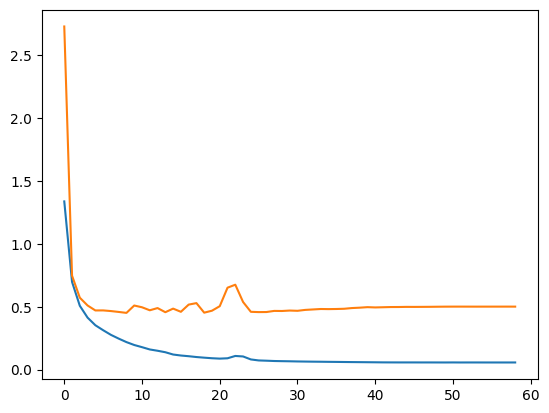

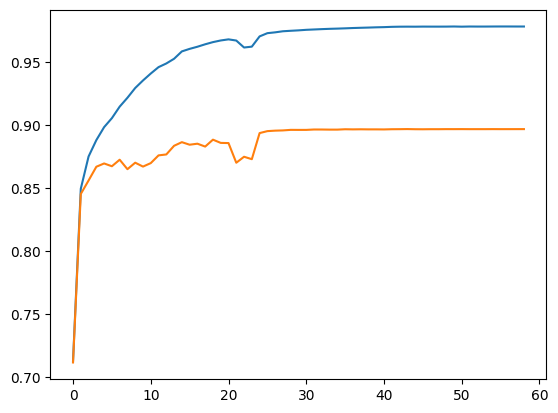

training_elements = 2330
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 552ms/step - categorical_accuracy: 0.9774 - loss: 0.0576
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 457ms/step - categorical_accuracy: 0.8967 - loss: 0.4980
Evaluacija nad trening skupom: [0.057582296431064606, 0.9773505330085754]
Evaluacija nad test skupom: [0.49804916977882385, 0.8966994881629944]


In [8]:
########################################################################################################################
# 7. TRENIRANJE MODELA
########################################################################################################################

hist = model.fit(data_gen_train,
                 epochs=1000,
                 validation_data=data_gen_valid,
                 shuffle=True,
                 callbacks=[save_model, csv_logger, early_stopping, reduce_lr],
                 verbose=1)

model.save(path, include_optimizer=False)

# SNIMANJE GRAFIKONA
plt.clf()
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.savefig(os.path.join(drive_results_folder, 'training_loss.png'))
plt.show()

plt.clf()
plt.plot(hist.history['categorical_accuracy'])
plt.plot(hist.history['val_categorical_accuracy'])
plt.savefig(os.path.join(drive_results_folder, 'training_accuracy.png'))
plt.show()

# EVALUACIJA MODELA
data_gen_train_nodataaug = DataProvider(batch_size, is_validation=False, data_augmentation=False)
res_train = model.evaluate(data_gen_train_nodataaug)
res_test = model.evaluate(data_gen_valid)
print("Evaluacija nad trening skupom:", res_train)
print("Evaluacija nad test skupom:", res_test)

Učitavanje modela
Priprema liste test podataka...
Obrada slika (učitavanje, predikcija i snimanje)...
Obrađeno 50 / 583 slika...
Obrađeno 100 / 583 slika...
Obrađeno 150 / 583 slika...
Obrađeno 200 / 583 slika...
Obrađeno 250 / 583 slika...
Obrađeno 300 / 583 slika...
Obrađeno 350 / 583 slika...
Obrađeno 400 / 583 slika...
Obrađeno 450 / 583 slika...
Obrađeno 500 / 583 slika...
Obrađeno 550 / 583 slika...


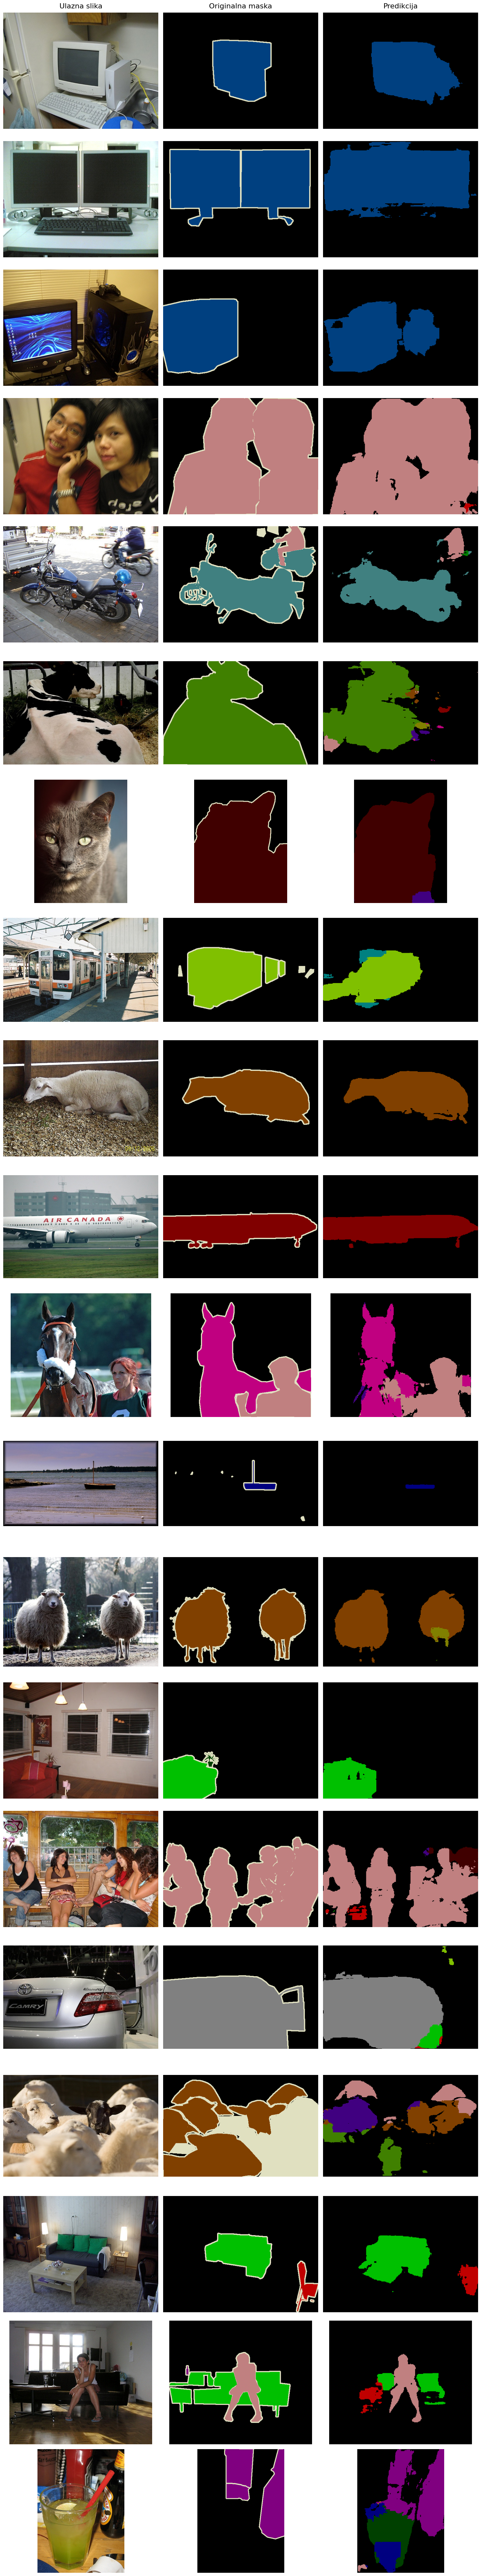

In [9]:
########################################################################################################################
# 8. UČITAVANJE MODELA I GENERISANJE PREDIKCIJA ZA TEST PODATKE
########################################################################################################################

# UČITAVANJE PRETHODNO SNIMLJENOG MODELA
print('Učitavanje modela')
model_path = os.path.join(drive_results_folder, 'trained_model.keras')
model = tf.keras.models.load_model(model_path, compile=False)

# PRIPREMA LISTE TEST PODATAKA (Putanja)
print('Priprema liste test podataka...')
test_data = []
cnt = 0
for filename_gt in train_images_gt:
    filename = filename_gt[:-4] + '.jpg'
    if cnt % 5 == 2:
        test_data.append((filename, filename_gt))
    cnt += 1

# PRIPREMA FOLDERA I GRID-A ZA PRIKAZ
eval_path = os.path.join(drive_results_folder, "eval")
if not os.path.exists(eval_path):
    os.makedirs(eval_path)

num_display = min(20, len(test_data))
fig, axes = plt.subplots(nrows=num_display, ncols=3, figsize=(15, 4 * num_display))

# GLAVNA PETLJA - PROCESIRANJE SLIKU PO SLIKU
print('Obrada slika (učitavanje, predikcija i snimanje)...')
for i in range(len(test_data)):
    filename, filename_gt = test_data[i]
    img_path = os.path.join(train_folder, filename)
    img_path_gt = os.path.join(train_folder_gt, filename_gt)
    img_path_pred = os.path.join(eval_path, filename_gt[:-4] + '_.png')

    # Učitavanje i skaliranje jedne slike
    img = cv.imread(img_path)
    img_resized = cv.resize(img, (image_size, image_size), interpolation=cv.INTER_LINEAR)

    # Model očekuje batch, pa dodajemo jednu "praznu" dimenziju napred -> oblik (1, 256, 256, 3)
    img_batch = np.expand_dims(img_resized, axis=0).astype(np.float32)

    # Predikcija samo za tu sliku (verbose=0 isključuje ispisivanje progress bar-a za svaku pojedinačnu sliku)
    pred = model.predict(img_batch, verbose=0)

    # Uzimamo izlaz za tu prvu sliku (indeks 0) i nalazimo najverovatniju klasu
    pred_classes = np.argmax(pred[0], axis=-1)

    # Skaliranje predikcije na dimenziju originalne Ground Truth slike
    img_gt = cv.imread(img_path_gt) # Učitavamo original samo zbog dimenzija
    img_pred_resized = cv.resize(pred_classes.astype(np.uint8), (img_gt.shape[1], img_gt.shape[0]), interpolation=cv.INTER_NEAREST)

    # Kopiranje fajlova i snimanje rezultata
    copyfile(img_path, os.path.join(eval_path, filename))
    copyfile(img_path_gt, os.path.join(eval_path, filename_gt))

    pil_image_pred = Image.fromarray(img_pred_resized)
    pil_image_pred.putpalette(palette)
    pil_image_pred.save(img_path_pred, 'PNG')

    # Prikaz u gridu (samo za prve num_display slike)
    if i < num_display:
        pil_img_input = Image.open(img_path)
        pil_image_gt = Image.open(img_path_gt)

        # Popunjavanje grid-a
        axes[i, 0].imshow(pil_img_input)
        axes[i, 1].imshow(pil_image_gt.convert('RGB'))
        axes[i, 2].imshow(pil_image_pred.convert('RGB'))

        # Uklanjamo numeričke ose i okvire
        axes[i, 0].axis('off')
        axes[i, 1].axis('off')
        axes[i, 2].axis('off')

        # Naslovi
        if i == 0:
            axes[i, 0].set_title("Ulazna slika", fontsize=16, pad=10)
            axes[i, 1].set_title("Originalna maska", fontsize=16, pad=10)
            axes[i, 2].set_title("Predikcija", fontsize=16, pad=10)

    # Ispisujemo napredak na svakih 50 slika
    if (i + 1) % 50 == 0:
        print(f"Obrađeno {i + 1} / {len(test_data)} slika...")

plt.tight_layout()
plt.show()